# **ML Workflow**

## **ML Part**

1. Problem Statement
2. Data Gathering (using any method as below)
	- Webscraping
	- Extract from API
	- Extract from Dbs
	- Provided by stake holders
3. Data Assesment
	- Explore data using pandas method to get a glimpse of data
	- Identify & make a note of all the issues which needs to be cleaned
4. Data Cleaning
	- Perform cleaning
5. EDA
	- Perform EDA (uni, bi & multi)
	- Understand target column relation with all the cols
	- Identify if new features to be created
6. Data Transformation & Feature Engineering
	- Perform data transformation & feature engineering as understood in EDA
7. EDA & Hypothesis Testing
	- Perform another round of EDA after feature engieering
	- Perform hypothesis testings
8. Experiments
	- Base Model
	- Multi Model to find best model
	- HP Tuning
9. Create DVC Pipeline
	- Data Cleaning
	- Data PreProcessing
	- Data Transformation
	- Model Trainer
	- Model Evaluation
		- Log the model, regressor & transformed in mlflow
		- extract and save model path, run id in **run_information.json**
	- Model Registry
		- Add dvc remote s3: dvc remote add -d myremote **your_bucket_name**
		- dvc status
		- dvc push
		- Push model to model registry in Staging stage
		- model registry tracks the version & stages of model

10. Create FastAPI around the model
	- pydantic model for data validation & type conversion where possible
	- Uvicorn server which is faster then flask, we will get faster prediction
	- Perform sample tests/predictions on swagger UI locally

		```{
		"ID": "0x1",
		"Delivery_person_ID": "BANGRES11DEL01",
		"Delivery_person_Age": "30",
		"Delivery_person_Ratings": "4.8",
		"Restaurant_latitude": 12.9716,
		"Restaurant_longitude": 77.5946,
		"Delivery_location_latitude": 12.9352,
		"Delivery_location_longitude": 77.6245,
		"Order_Date": "2022-03-15",
		"Time_Orderd": "11:30",
		"Time_Order_picked": "11:45",
		"Weatherconditions": "Sunny",
		"Road_traffic_density": "High",
		"Vehicle_condition": 2,
		"Type_of_order": "Meal",
		"Type_of_vehicle": "motorcycle",
		"multiple_deliveries": "1",
		"Festival": "No",
		"City": "Metropolitian"
		}```

## **Ops part**

- **CI Pipeline**

**What to execute in CI/CD Pipeline**

- Pull data from DVC & Run DVC: `dvc pull` & `dvc repro`
- Execute performance tests on staged model against predefined thresholds (RMSE, R², MAE) and validate success criteria.
- If performance test succeeds, promote model from "Staging" to "Production" stage in MLflow Model Registry with performance metadata.
- If above tests pass, build Docker image, run Docker container and test the production model through API endpoints.
- Test production model via API endpoints (`/health`, `/predict`, `/docs`) for request/response validation, edge cases, and response time (<500ms) in Docker.
- Once all tests pass, push Docker image to ECR Repo.
- **Once Docker image is in ECR repo, we can deploy via CI/CD on:**
    1. EC2 using CodeDeploy (Configure ASG, Loadbalancer & Deployment method manually)
    2. ECS (Elastic Kubernetes service)
    3. EKS (Elastic Kubernetes service)

    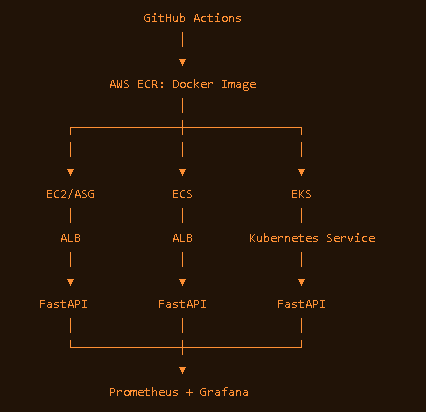

- Integrate Monitoring using ****Prometheus & Grafana****
- Integrate retraining using ****Airflow****

### 1. EC2 + ASG + LoadBalancer + CodeDeploy

### 2. ECS

### 3. EKS